# EML Network Learning Sine Function

This notebook demonstrates an EML (Exponential-Minus-Logarithm) neural network learning to approximate a sine function from 100 randomly sampled datapoints.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from micrograd.engine import Value
from micrograd.nn import EMLMLP

## Generate Training Data

Create 100 random datapoints sampled from a sine function.

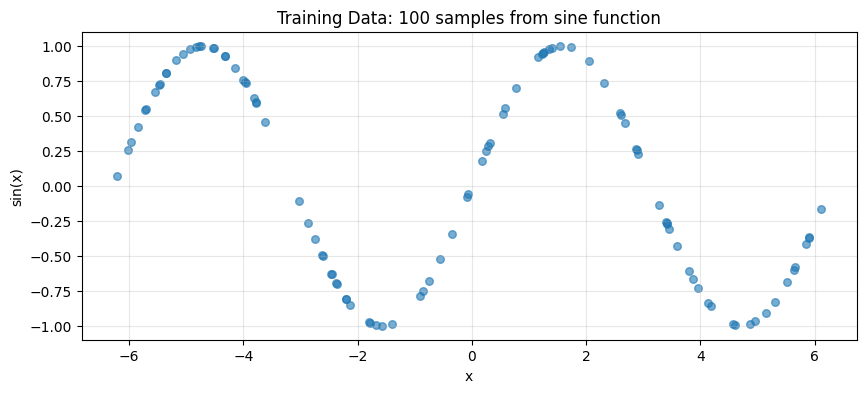

In [2]:
# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Generate 100 datapoints from sine function
n_samples = 100
x_data = np.random.uniform(-2*np.pi, 2*np.pi, n_samples)
y_data = np.sin(x_data)

# Normalize x to [-1, 1] for numerical stability of the EML network
# (exp(x) in EML neurons overflows if x is large)
x_norm = x_data / (2*np.pi)

# Visualize the training data
plt.figure(figsize=(10, 4))
plt.scatter(x_data, y_data, alpha=0.6, s=30)
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.title('Training Data: 100 samples from sine function')
plt.grid(True, alpha=0.3)
plt.show()

## Build and Train the EML Network

Create an EMLMLP with an input layer (1 neuron for x input), hidden layers, and 1 output neuron for the sine value.

In [3]:
# Create EML MLP: 1 input -> 8 hidden -> 8 hidden -> 1 output
model = EMLMLP(1, [8, 8, 1])

print(f"Model architecture:")
for layer in model.layers:
    print(f"  {layer}")

n_params = len(model.parameters())
print(f"\nTotal parameters: {n_params}")

Model architecture:
  Layer 'eml_l0' of [EMLNeuron(1), EMLNeuron(1), EMLNeuron(1), EMLNeuron(1), EMLNeuron(1), EMLNeuron(1), EMLNeuron(1), EMLNeuron(1)]
  Layer 'eml_l1' of [EMLNeuron(8), EMLNeuron(8), EMLNeuron(8), EMLNeuron(8), EMLNeuron(8), EMLNeuron(8), EMLNeuron(8), EMLNeuron(8)]
  Layer 'eml_l2' of [EMLNeuron(8)]

Total parameters: 194


## Training Loop

Train the network using gradient descent to minimize mean squared error.

In [4]:
# Training parameters
learning_rate = 0.005
epochs = 200

loss_history = []

for epoch in range(epochs):
    total_loss = Value(0.)
    for xi, yi in zip(x_norm, y_data):
        x_input = [Value(float(xi))]
        y_pred = model(x_input)
        loss = (y_pred - Value(float(yi))) ** 2.
        total_loss = total_loss + loss

    avg_loss = total_loss * Value(1.0 / n_samples)
    loss_val = avg_loss.data.real if isinstance(avg_loss.data, complex) else avg_loss.data
    loss_history.append(float(loss_val))

    model.zero_grad()
    avg_loss.backward()

    for p in model.parameters():
        p.data = p.data - learning_rate * p.grad

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss_history[-1]:.6f}")

print(f"\nTraining complete! Final loss: {loss_history[-1]:.6f}")

Epoch 20/200, Loss: 0.667365


Epoch 40/200, Loss: 0.357096


Epoch 60/200, Loss: 0.398746


Epoch 80/200, Loss: 0.176061


Epoch 100/200, Loss: 0.662775


Epoch 120/200, Loss: 0.104006


Epoch 140/200, Loss: 0.028854


Epoch 160/200, Loss: 0.018387


Epoch 180/200, Loss: 0.021780


Epoch 200/200, Loss: 0.022018

Training complete! Final loss: 0.022018


## Visualize Training Loss

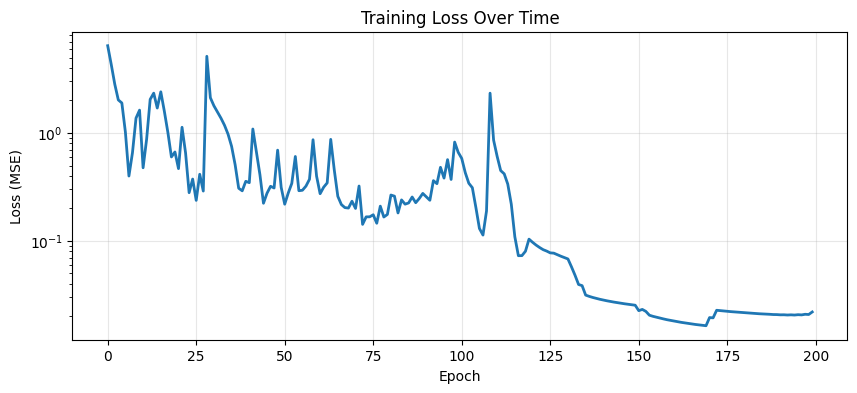

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(loss_history, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

## Evaluate on Test Set

Evaluate the trained model on the original training data and compare with the true sine function.

In [6]:
# Generate evaluation points
x_eval = np.linspace(-2*np.pi, 2*np.pi, 200)
y_eval_true = np.sin(x_eval)
y_eval_pred = []

# Predict on evaluation set (using same normalization as training)
for x_val in x_eval:
    x_input = [Value(float(x_val / (2*np.pi)))]
    y_pred = model(x_input)
    val = y_pred.data.real if isinstance(y_pred.data, complex) else y_pred.data
    y_eval_pred.append(float(val))

y_eval_pred = np.array(y_eval_pred)

mse = np.mean((y_eval_pred - y_eval_true) ** 2)
print(f"Mean Squared Error on evaluation set: {mse:.6f}")

Mean Squared Error on evaluation set: 0.032002


## Visualization: Model Prediction vs True Sine Function

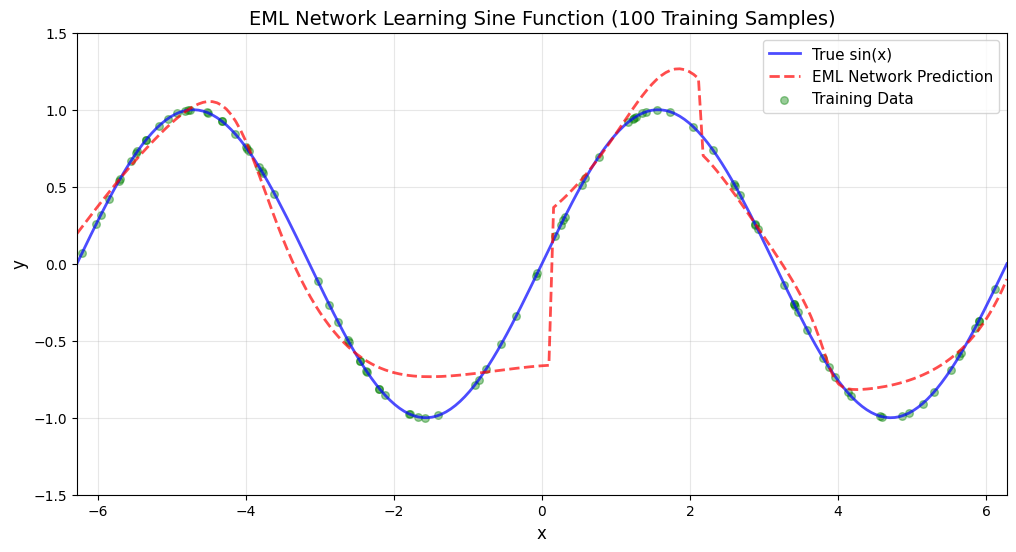

Visualization complete!


In [7]:
plt.figure(figsize=(12, 6))

# Plot true sine function
plt.plot(x_eval, y_eval_true, 'b-', linewidth=2, label='True sin(x)', alpha=0.7)

# Plot model prediction
plt.plot(x_eval, y_eval_pred, 'r--', linewidth=2, label='EML Network Prediction', alpha=0.7)

# Plot training data
plt.scatter(x_data, y_data, alpha=0.4, s=30, label='Training Data', color='green')

plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('EML Network Learning Sine Function (100 Training Samples)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(-2*np.pi, 2*np.pi)
plt.ylim(-1.5, 1.5)
plt.show()

print(f"Visualization complete!")

## Residuals Analysis

Analyze the prediction errors.

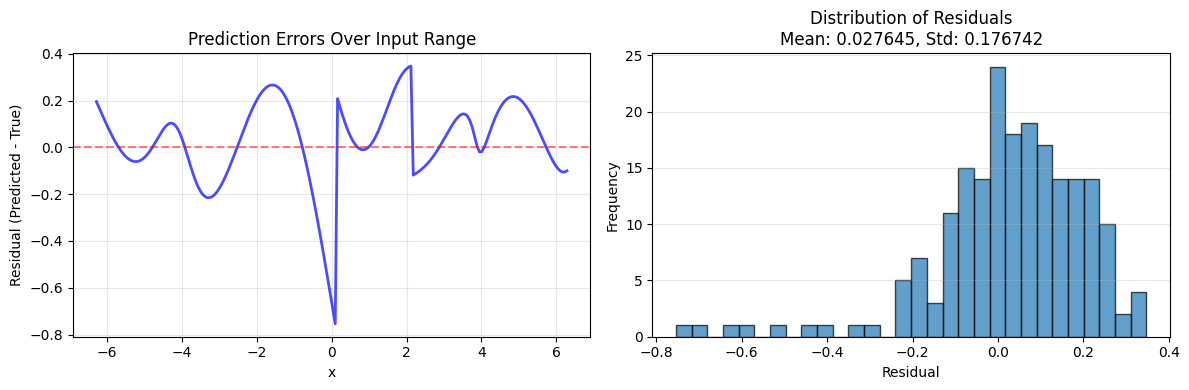

Max absolute error: 0.754203


In [8]:
residuals = y_eval_pred - y_eval_true

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals over x
axes[0].plot(x_eval, residuals, 'b-', alpha=0.7, linewidth=2)
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Residual (Predicted - True)')
axes[0].set_title('Prediction Errors Over Input Range')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=30, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Distribution of Residuals\nMean: {np.mean(residuals):.6f}, Std: {np.std(residuals):.6f}')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Max absolute error: {np.max(np.abs(residuals)):.6f}")